# EDA Emosi Marcus Aurelius
## Business Questions
1. Apakah jumlah data tiap emosi merata?
2. Apakah panjang teks berbeda antar emosi?
3. Kata apa yang paling sering muncul per emosi?

In [4]:
!pip install wordcloud

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [6]:
df = pd.read_csv('dataset_markus_erelius_clean.csv', encoding='utf-8', engine='python', on_bad_lines='skip')
df.columns = df.columns.str.strip().str.replace(';','', regex=False)
df.head()

,label,text
0,netral,marcus aurelius mengingatkan: kita hidup hanya...
1,senang,marcus aurelius mengingatkan: hidup singkat - ...
2,netral,hiduplah dengan bijak: karena dalam kekuasaanm...
3,kaget,seperti kata marcus aurelius: takut akan perub...
4,senang,kata marcus aurelius: hidup bahagia memerlukan...


In [7]:
df['word_count'] = df['text'].astype(str).str.split().str.len()
df['char_length'] = df['text'].astype(str).str.len()

## Pertanyaan 1 - Distribusi Emosi

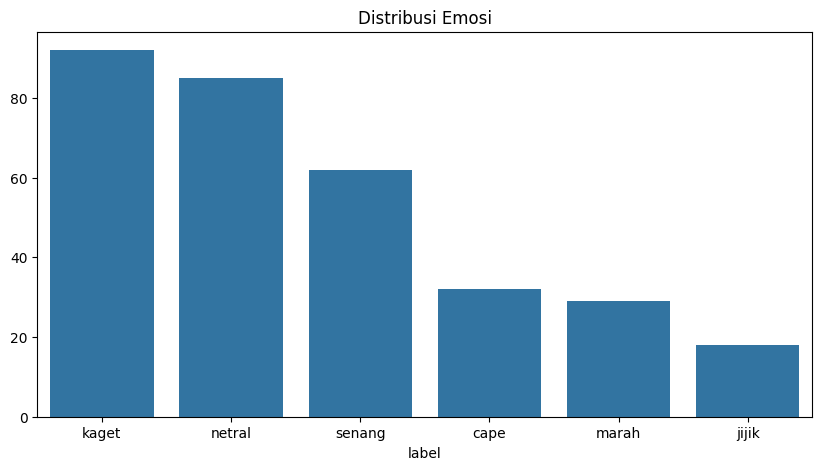

In [8]:
emotion_counts = df['label'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Distribusi Emosi')
plt.show()

## Pertanyaan 2 - Panjang Teks

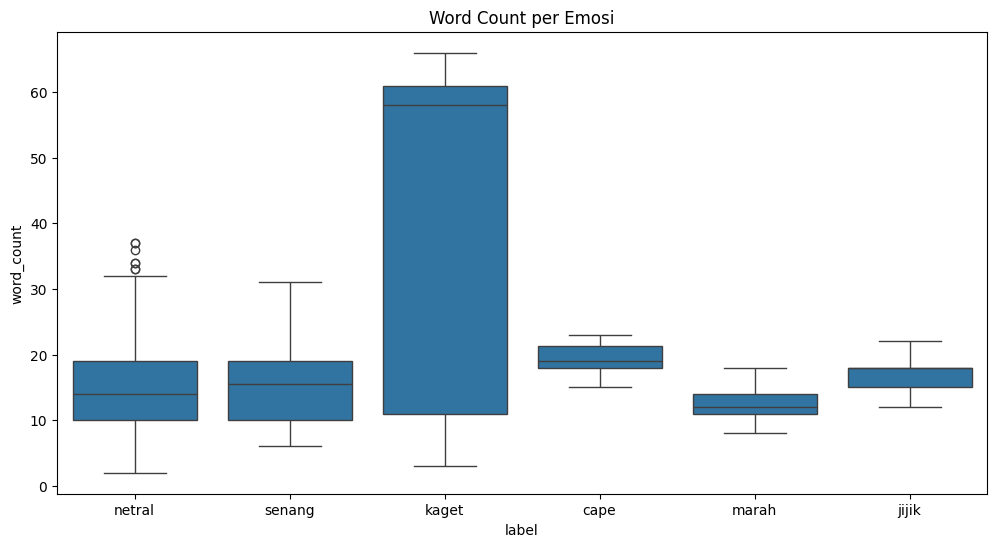

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Word Count per Emosi')
plt.show()

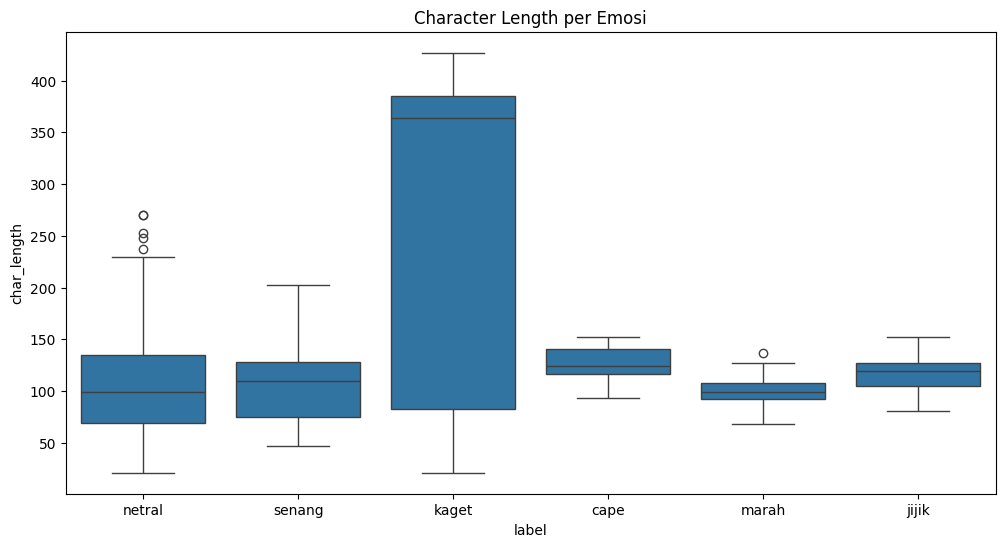

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='label', y='char_length')
plt.title('Character Length per Emosi')
plt.show()

## Pertanyaan 3 - Kata Dominan

In [11]:
selected_emotion = df['label'].unique()[0]
text = ' '.join(df[df['label']==selected_emotion]['text'])
counter = Counter(text.lower().split())
top_words = pd.DataFrame(counter.most_common(10), columns=['Kata','Frekuensi'])
top_words

,Kata,Frekuensi
0,marcus,55
1,untuk,43
2,yang,42
3,tidak,39
4,kamu,33
5,pesan,30
6,apa,20
7,kita,19
8,hidup,19
9,memiliki,18


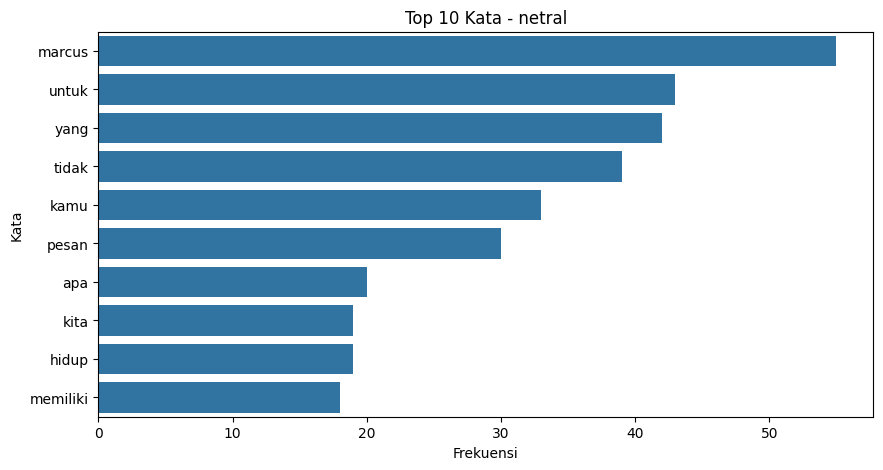

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_words, x='Frekuensi', y='Kata')
plt.title(f'Top 10 Kata - {selected_emotion}')
plt.show()

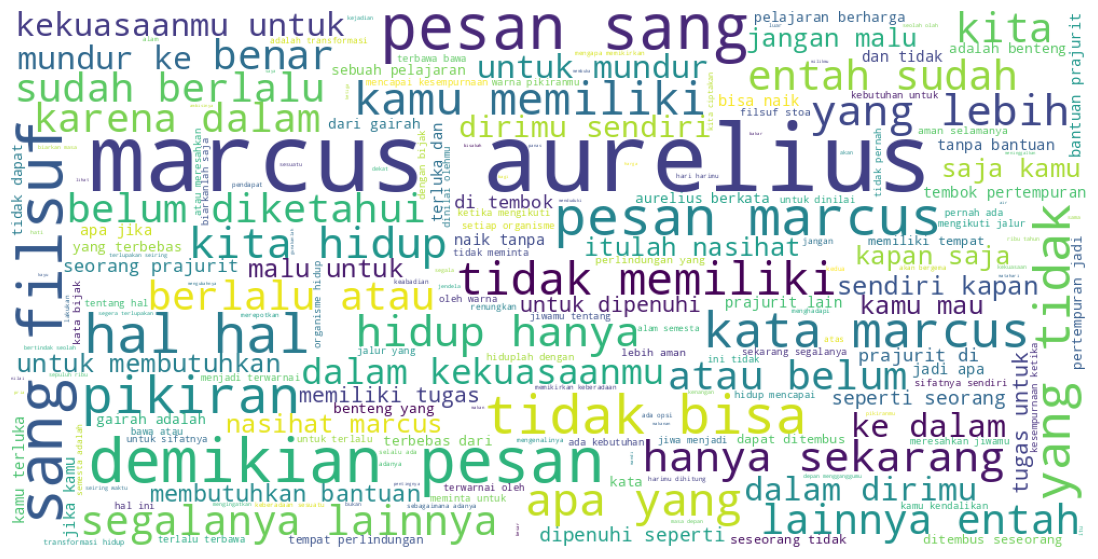

In [13]:
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()